# Customer Clustering Model - RFM Segmentation

## Technical Methodology
In this notebook, I turn the RFM table into a segmentation model that a retail team could actually use. My focus is not just on fitting K-Means, but on making sure the preprocessing, cluster choice, and interpretation all hold up in a real business conversation.

## Why run a requirements check first
This notebook touches modeling and visualization libraries, so I prefer to verify the environment before I spend time tuning clusters. It is a simple habit that saves time when I rerun the project or share it.

In [1]:
# Verify every major library first because clustering notebooks can fail late if even one dependency is missing.
required_libraries = [
    "pandas",
    "numpy",
    "sqlite3",
    "seaborn",
    "matplotlib",
    "sklearn",
    "plotly"
]

print("Requirements check:")
for library_name in required_libraries:
    # Import each library here so I can catch setup issues before the modeling flow gets underway.
    __import__(library_name)
    print(f"- {library_name}: available")

Requirements check:
- pandas: available
- numpy: available
- sqlite3: available
- seaborn: available
- matplotlib: available
- sklearn: available
- plotly: available


## Why rebuild RFM from SQLite in this notebook
I wanted this modeling notebook to stand on its own instead of depending on variables left behind by another notebook session. Pulling from `retail.db` forces me to treat the database as the source of truth and makes the pipeline more reproducible.

In [2]:
# Import the full modeling stack here so the notebook reads top-to-bottom like a real project workflow.
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Set a clean seaborn theme early so every chart looks consistent while I explore and explain the model.
sns.set_theme(style="whitegrid")

# Load the cleaned transactions from SQLite because I want the model to start from the exact same source every time.
database_path = "retail.db"
sqlite_connection = sqlite3.connect(database_path)
df_transactions = pd.read_sql_query("SELECT * FROM transactions", sqlite_connection)
sqlite_connection.close()

# Validate the expected columns up front because clustering errors are much easier to diagnose before feature engineering begins.
required_columns = ["CustomerID", "Invoice", "InvoiceDate", "Quantity", "Price"]
missing_columns = [column for column in required_columns if column not in df_transactions.columns]
if missing_columns:
    raise KeyError(f"Missing required columns in transactions table: {missing_columns}")

# Create a working copy so I can transform dates and numeric fields without touching the raw SQL pull.
df_rfm_source = df_transactions.copy()

# Coerce these fields early because RFM depends on reliable dates and numeric spend values.
df_rfm_source["InvoiceDate"] = pd.to_datetime(df_rfm_source["InvoiceDate"], errors="coerce")
df_rfm_source["Quantity"] = pd.to_numeric(df_rfm_source["Quantity"], errors="coerce")
df_rfm_source["Price"] = pd.to_numeric(df_rfm_source["Price"], errors="coerce")

# Drop unusable rows here so bad records do not ripple into the clustering features.
df_rfm_source = df_rfm_source.dropna(subset=["InvoiceDate", "Quantity", "Price", "CustomerID"])

# Anchor Recency using one day after the latest invoice, which keeps the feature consistent with the RFM notebook.
snapshot_date = df_rfm_source["InvoiceDate"].max() + pd.Timedelta(days=1)

# Compute spend at the transaction-line level so Monetary reflects actual revenue contribution.
df_rfm_source["LineTotal"] = df_rfm_source["Quantity"] * df_rfm_source["Price"]

# Collapse the transaction table to one row per customer because clustering individual invoices would answer the wrong business question.
df_rfm = (
    df_rfm_source.groupby("CustomerID").agg(
        Recency=("InvoiceDate", lambda invoice_dates: (snapshot_date - invoice_dates.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("LineTotal", "sum")
    )
).reset_index()

# Remove non-positive monetary customers because they do not fit the commercial value story I want this model to explain.
df_rfm = df_rfm[df_rfm["Monetary"] > 0].copy()

print(f"RFM shape for clustering: {df_rfm.shape}")

RFM shape for clustering: (4312, 4)


## Why check skewness before clustering
RFM features rarely behave nicely out of the box, especially Monetary. I plot the raw distributions here because I want to see how aggressive the skew is before I commit to a transformation strategy.

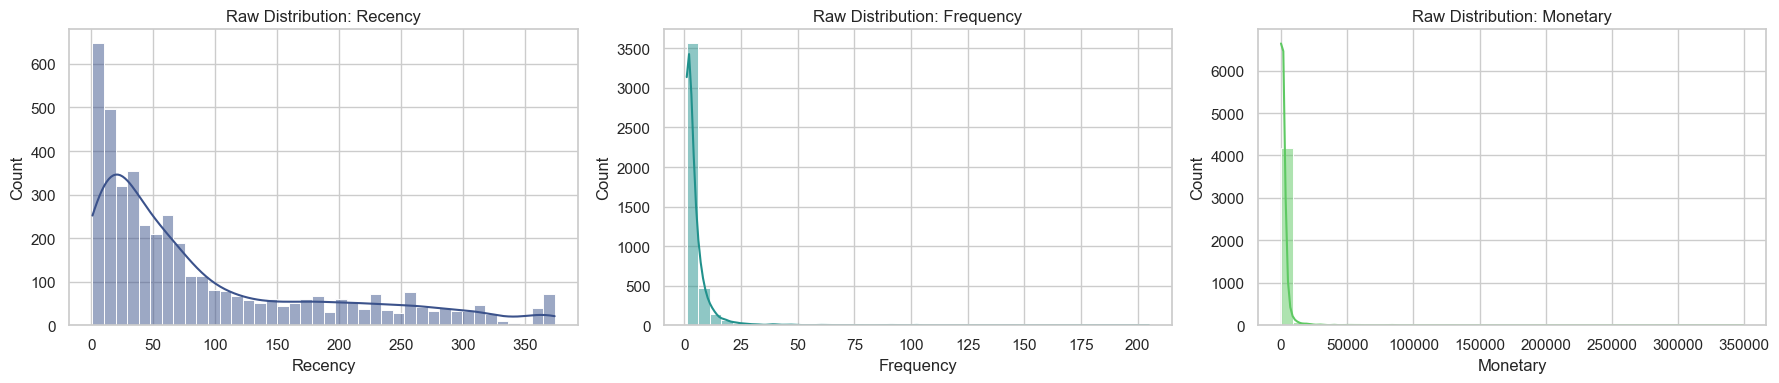

In [3]:
# Visualize the raw RFM distributions first because Monetary, in particular, can dominate the model if I ignore its long tail.
rfm_features = ["Recency", "Frequency", "Monetary"]
viridis_colors = sns.color_palette("viridis", n_colors=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for index, feature_name in enumerate(rfm_features):
    # Keep the palette consistent so the plots look polished without distracting from the shape of the distributions.
    sns.histplot(
        data=df_rfm,
        x=feature_name,
        bins=40,
        kde=True,
        color=viridis_colors[index],
        ax=axes[index]
    )
    axes[index].set_title(f"Raw Distribution: {feature_name}")
    axes[index].set_xlabel(feature_name)
    axes[index].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Why log-transform and scale the features
I had to be careful here because Monetary was heavily right-skewed and could easily bully the rest of the model. I use `np.log1p` to soften the long tails, then I scale the features because K-Means measures distance and I want Recency, Frequency, and Monetary to compete fairly.

In [4]:
# Isolate the three RFM features here because those are the signals I want K-Means to cluster on.
df_rfm_features = df_rfm[["Recency", "Frequency", "Monetary"]].copy()

# Apply log1p because the raw Monetary distribution is too skewed to feed directly into a distance-based algorithm.
df_rfm_log = np.log1p(df_rfm_features)

# Scale the features here because K-Means is sensitive to distance; I do not want Monetary values to bully my Frequency stats.
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(df_rfm_log)

# Convert the scaled matrix back to a DataFrame so I can inspect it more comfortably during debugging.
df_rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    columns=["Recency", "Frequency", "Monetary"],
    index=df_rfm.index
)

display(df_rfm_scaled.head())

,Recency,Frequency,Monetary
0,0.966262,1.613017,-0.540688
1,-1.900165,-0.394693,0.447651
2,0.355000,-0.981910,-0.943904
3,-0.055302,0.021945,0.996204
4,-1.054928,-0.981910,-0.707671


## Why use the Elbow Method
I use the Elbow Method as a decision aid, not as a law. It helps me understand how much compactness I gain as I increase `K`, but I still have to weigh that against whether the final segments would be useful to a real business team.

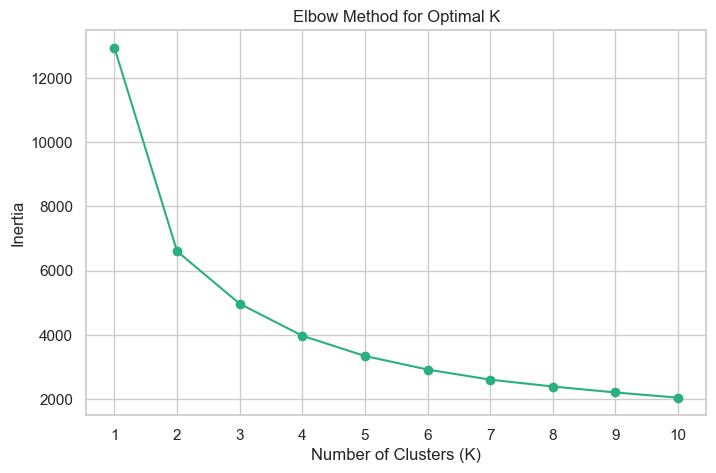

In [5]:
# Calculate inertia across several K values so I can see where the gains from additional clusters start to flatten out.
cluster_range = range(1, 11)
inertia_values = []

for k_value in cluster_range:
    # Keep the random state fixed so I can trust the curve when I rerun the notebook.
    kmeans_model = KMeans(n_clusters=k_value, random_state=42, n_init=10)
    kmeans_model.fit(df_rfm_scaled)
    inertia_values.append(kmeans_model.inertia_)

# Plot the elbow curve next because it gives me a quick visual trade-off between simplicity and fit.
viridis_curve_color = sns.color_palette("viridis", n_colors=10)[6]
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia_values, marker="o", color=viridis_curve_color)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(cluster_range))
plt.show()

## Why finalize the model with K=4
The elbow gave me a reasonable case for `K=2`, but I chose `K=4` because two segments would have been too blunt for the business story I wanted to tell. Four clusters gave me room to separate top customers, stable repeat buyers, newer growth opportunities, and customers who were slipping away.

In [6]:
# Lock the final model at K=4 because that gives me customer personas that are more actionable than a coarse two-cluster split.
optimal_k = 4

# Train the final K-Means model on the scaled feature space so each RFM signal contributes on comparable footing.
kmeans_final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final_model.fit_predict(df_rfm_scaled)

# Bring the cluster labels back onto the original RFM table because that is the version business stakeholders can actually read.
df_rfm_clustered = df_rfm.copy()
df_rfm_clustered["Cluster"] = cluster_labels.astype(int)

# Summarize each cluster with original-scale means and counts so I can interpret business value without reversing transformations in my head.
df_profile = (
    df_rfm_clustered
    .groupby("Cluster", as_index=False)
    .agg(
        CustomerCount=("CustomerID", "count"),
        Recency=("Recency", "mean"),
        Frequency=("Frequency", "mean"),
        Monetary=("Monetary", "mean")
    )
)

# Sort by Monetary so the highest-value clusters surface first when I discuss the results.
df_profile = df_profile.sort_values(by="Monetary", ascending=False).reset_index(drop=True)

print("Final K-Means model completed with K=4.")
display(df_profile)


Final K-Means model completed with K=4.


,Cluster,CustomerCount,Recency,Frequency,Monetary
0,1,776,13.889175,13.581186,7422.654933
1,3,1190,82.659664,4.136975,1775.159700
2,0,949,23.139094,2.053741,565.798399
3,2,1397,187.566929,1.289907,302.534232


## Why visualize the clusters in 3D
The profile table gives me the numbers, but the 3D view helps me see how the segments separate across all three RFM dimensions at once. It is not the whole argument, but it is a helpful way to communicate the result quickly.

In [7]:
# Use an interactive 3D plot here so I can inspect how the clusters separate across all three RFM dimensions.
figure_3d_clusters = px.scatter_3d(
    df_rfm_clustered,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Cluster",
    color_continuous_scale="Viridis",
    title="Customer Segments in RFM Space (K-Means)",
    labels={
        "Recency": "Recency (days)",
        "Frequency": "Frequency (unique invoices)",
        "Monetary": "Monetary (total spend)",
        "Cluster": "Cluster"
    },
    opacity=0.8,
    height=700
)

# Bump the marker sizing and tighten the margins so the chart reads more like a presentation asset than a default notebook plot.
figure_3d_clusters.update_traces(marker=dict(size=4))
figure_3d_clusters.update_layout(margin=dict(l=0, r=0, b=0, t=50))

# Render the figure last so I can discuss the shape of the clusters alongside the profile table.
figure_3d_clusters.show()